# Notebook 07 - Attention Analysis & Model Interpretability

This notebook focuses on model interpretability using attention mechanisms from transformer models. It extracts token-level attention weights and reconstructs them into word-level importance scores.

Multiple levels of analysis are performed:
- Sample-level attention visualisation for different prediction outcomes (TP, TN, FP, FN)
- Aggregate attention analysis across multiple samples
- Identification of top attended words for each predicted class
- Clinical domain-level analysis grouping terms into meaningful categories
- Section-level analysis mapping attention to parts of clinical narratives

The goal is to understand how the model makes decisions and whether it focuses on clinically relevant information. This enhances trustworthiness and provides insights into model behaviour beyond performance metrics.

## Attention Analysis Setup and Environment Initialisation

This section prepares the environment for analysing attention patterns in transformer models. It includes the required library imports, configuration parameters, and file paths necessary for loading trained models and their prediction outputs.

Core libraries for data handling, model loading, and visualisation are initialised to support attention-based interpretability analysis. Pre-trained transformer models and their corresponding checkpoints are accessed dynamically using stored configurations and result files.

An output directory is created to store attention visualisations, ensuring that results are organised and reproducible. Global plotting settings are also defined to maintain consistent visual style across all attention-related figures.

This setup enables systematic exploration of model attention behaviour, supporting deeper interpretation of how transformer models process input text during prediction.

In [1]:
# System Path Configuration
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

# Core Data Handling Libraries
import pandas as pd
import numpy as np
import pickle

# PyTorch and Transformer Components
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Visualisation and Warning Management
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings

# Suppress non-critical warnings for cleaner notebook output
warnings.filterwarnings('ignore')

# Checkpoint detection utilities
import glob, json as _json

# Scikit-learn Utilities
from sklearn.model_selection import train_test_split

# Project Configuration Parameters 
from config import (
    LABELLED_DATASET,
    ALL_RESULTS_CSV,
    DISTILBERT_MODEL_ID, DISTILBERT_DIR, DISTILBERT_PREDS_PKL,
    PUBMEDBERT_MODEL_ID, PUBMEDBERT_DIR, PUBMEDBERT_PREDS_PKL,
    BIOBERT_MODEL_ID,    BIOBERT_DIR,    BIOBERT_PREDS_PKL,
    PLOTS_DIR,
    MAX_LENGTH,
    RANDOM_STATE,
    TEST_SIZE,
    VAL_SIZE,
)

# Attention Analysis Output Directory Setup
ATTENTION_DIR = PLOTS_DIR / "attention_analysis"
ATTENTION_DIR.mkdir(parents=True, exist_ok=True)

# Global Plotting Styles
plt.rcParams.update({
    'figure.dpi':120,
    'axes.spines.top':False,
    'axes.spines.right':False,
    'font.size':11,
})

# Colour Palette for Visualisations
PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#2A9D8F', '#8338EC']

d:\Lancaster University Coursework\Term 2\SCC 453 - Natural Language Processing and Language Models\Coursework Code\using mimic data\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Best Model Selection and Attention Model Preparation

This section identifies the best-performing transformer model and prepares it for attention-based analysis. Model selection is based on evaluation results, ensuring that subsequent interpretability analysis is conducted on the most effective model.

The best transformer is determined using ROC-AUC from the aggregated results. Once identified, the corresponding model configuration, directory, and prediction outputs are retrieved dynamically from the model registry.

The tokenizer and trained model are then loaded, with attention outputs explicitly enabled. The appropriate checkpoint is automatically selected, prioritising the best checkpoint recorded during training or the most recent valid checkpoint available.

Finally, the test dataset is reconstructed using the same data split configuration as in the training phase, and saved prediction outputs are loaded. This ensures consistency between evaluation and attention analysis, allowing reliable interpretation of model behaviour.

In [2]:
# Device Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

# Determine Best Transformer Model
all_results = pd.read_csv(ALL_RESULTS_CSV)
transformer_results = all_results[all_results['Type'] == 'Transformer']
best_model_name = transformer_results.sort_values(
    'ROC_AUC', ascending=False
).iloc[0]['Model']

# Model Registry Mapping
MODEL_REGISTRY = {
    'DistilBERT' : (DISTILBERT_MODEL_ID,  DISTILBERT_DIR,  DISTILBERT_PREDS_PKL),
    'PubMedBERT' : (PUBMEDBERT_MODEL_ID,  PUBMEDBERT_DIR,  PUBMEDBERT_PREDS_PKL),
    'BioBERT'    : (BIOBERT_MODEL_ID,     BIOBERT_DIR,     BIOBERT_PREDS_PKL),
}
best_model_id, best_model_dir, best_preds_pkl = MODEL_REGISTRY[best_model_name]

# Tokenizer Initialisation
tokenizer = AutoTokenizer.from_pretrained(best_model_id)

# Checkpoint Resolution
model_path = best_model_dir
trainer_state_path = os.path.join(model_path, 'trainer_state.json')

if os.path.exists(trainer_state_path):
    with open(trainer_state_path) as _f:
        state = _json.load(_f)

    best_ckpt = state.get('best_model_checkpoint', None)

    if best_ckpt and os.path.exists(best_ckpt):
        model_path = best_ckpt
    else:
        ckpt_dirs = sorted(glob.glob(os.path.join(best_model_dir, 'checkpoint-*')))
        valid = [d for d in ckpt_dirs if os.path.exists(os.path.join(d, 'config.json'))]

        if valid:
            model_path = valid[-1]
else:
    ckpt_dirs = sorted(glob.glob(os.path.join(best_model_dir, 'checkpoint-*')))
    valid = [d for d in ckpt_dirs if os.path.exists(os.path.join(d, 'config.json'))]

    if valid:
        model_path = valid[-1]

# Model Loading with Attention Outputs
model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    output_attentions=True,
    ignore_mismatched_sizes=True,
)

model.to(device)
model.eval()

# Dataset Reconstruction
df = pd.read_csv(LABELLED_DATASET)
X = df['narrative'].to_numpy(dtype=str)
y = df['readmission_30d'].to_numpy(dtype=int)

_, X_temp, _, y_temp = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# Load Saved Predictions
with open(best_preds_pkl, 'rb') as f:
    best_preds = pickle.load(f)

y_pred = best_preds['y_pred']
y_prob = best_preds['y_prob']

# Summary Output
print(f'Test set : {len(X_test):,} samples')
print(f'Test ROC-AUC (saved) : {best_preds["roc_auc"]:.4f}')

Device : cuda


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1022.54it/s, Materializing param=classifier.weight]                                     


Test set : 3,610 samples
Test ROC-AUC (saved) : 0.7067


## Attention Extraction and Token Processing

This section defines the methodology for extracting and processing attention weights from the transformer model. Attention analysis enables interpretation of which parts of the input text contribute most to the model’s predictions.

An attention extraction function is implemented to obtain attention scores across all layers and heads. These scores are averaged to produce a single attention value per token, representing the overall importance assigned by the model.

To improve interpretability, subword tokens are reconstructed into complete words by merging continuation tokens. This ensures that attention scores correspond to meaningful textual units rather than fragmented subword pieces.

A filtering step is applied to remove non-informative tokens such as punctuation, stopwords, and numerical values. The resulting processed tokens and attention weights provide a cleaner and more interpretable representation of model focus during prediction.

In [3]:
# Attention Extraction Function
def get_attention_weights(text, model, tokenizer, max_length=MAX_LENGTH, device=device):
    # Tokenise and encode input text
    enc = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='pt'
    )
    enc = {k: v.to(device) for k, v in enc.items()}

    # Run model inference without gradient tracking
    with torch.no_grad():
        outputs = model(**enc)

    # Stack attention outputs across layers
    attn_layers = torch.stack(outputs.attentions)
    attn_layers = attn_layers.squeeze(1)

    # Average attention across layers and heads
    attn_mean = attn_layers.mean(dim=0)
    attn_mean = attn_mean.mean(dim=0)

    # Compute received attention per token
    attn_recv = attn_mean.mean(dim=0).cpu().numpy()

    # Mask out padding tokens
    mask = enc['attention_mask'][0].cpu().numpy()
    attn_recv = attn_recv * mask

    # Convert input IDs back to tokens
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0].cpu().numpy())

    return tokens, attn_recv, outputs.logits[0].cpu().numpy()


# Tokens to Filter
SKIP_TOKENS = {
    '.', ',', '(', ')', ':', ';', '-', '/', '!', '?', "'", '"',
    '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
    'and', 'or', 'the', 'a', 'an', 'is', 'are', 'was', 'has', 'have',
    'no', 'not', 'per', 'with', 'for', 'of', 'in', 'at', 'to', 'this',
    'that', 'be', 'by', 'as', 'it', 'its', 'was', 'were', 'been', 'unitsml', 'syringe',
}


# Subword-to-Word Reconstruction Function
def tokens_to_words(tokens, attn):
    words = []
    word_attn = []
    cur_word = ''
    cur_attn = 0.0

    for tok, a in zip(tokens, attn):
        # Skip special tokens and finalise current word if needed
        if tok in ('[CLS]', '[SEP]', '[PAD]', '<s>', '</s>'):
            if cur_word:
                words.append(cur_word)
                word_attn.append(cur_attn)
                cur_word = ''
                cur_attn = 0.0
            continue

        # Append continuation subwords to the current token
        if tok.startswith('##'):
            cur_word += tok[2:]
            cur_attn += float(a)
        else:
            # Save completed word before starting a new one
            if cur_word:
                words.append(cur_word)
                word_attn.append(cur_attn)
            cur_word = tok
            cur_attn = float(a)

    # Append final word if present
    if cur_word:
        words.append(cur_word)
        word_attn.append(cur_attn)

    # Lowercase and filter non-informative tokens
    filtered_words = []
    filtered_attn = []

    for w, a in zip(words, word_attn):
        w_lower = w.lower().strip()
        if (
            w_lower not in SKIP_TOKENS
            and len(w_lower) >= 3
            and not w_lower.isdigit()
            and not all(c in '.,;:()-/' for c in w_lower)
        ):
            filtered_words.append(w_lower)
            filtered_attn.append(a)

    return filtered_words, np.array(filtered_attn)


# Summary Output
print(f'Skip token filter: {len(SKIP_TOKENS)} tokens')

Skip token filter: 52 tokens


## Attention-Based Analysis Across Prediction Outcomes

This section presents attention visualisations for representative samples across different prediction outcomes. Analysing attention in correctly and incorrectly classified cases provides insight into how the model makes decisions.

Samples are selected from four categories: true positives, true negatives, false negatives, and false positives. For each category, the highest-confidence instance is chosen to highlight model behaviour under strong prediction signals.

Attention weights are extracted, aggregated, and mapped to reconstructed words, with the top contributing terms visualised. Clinically relevant keywords are highlighted to assess whether the model focuses on meaningful medical concepts during prediction.

By comparing attention patterns across these outcomes, this analysis reveals differences in model reasoning, highlights potential failure modes, and supports interpretability of transformer-based predictions.

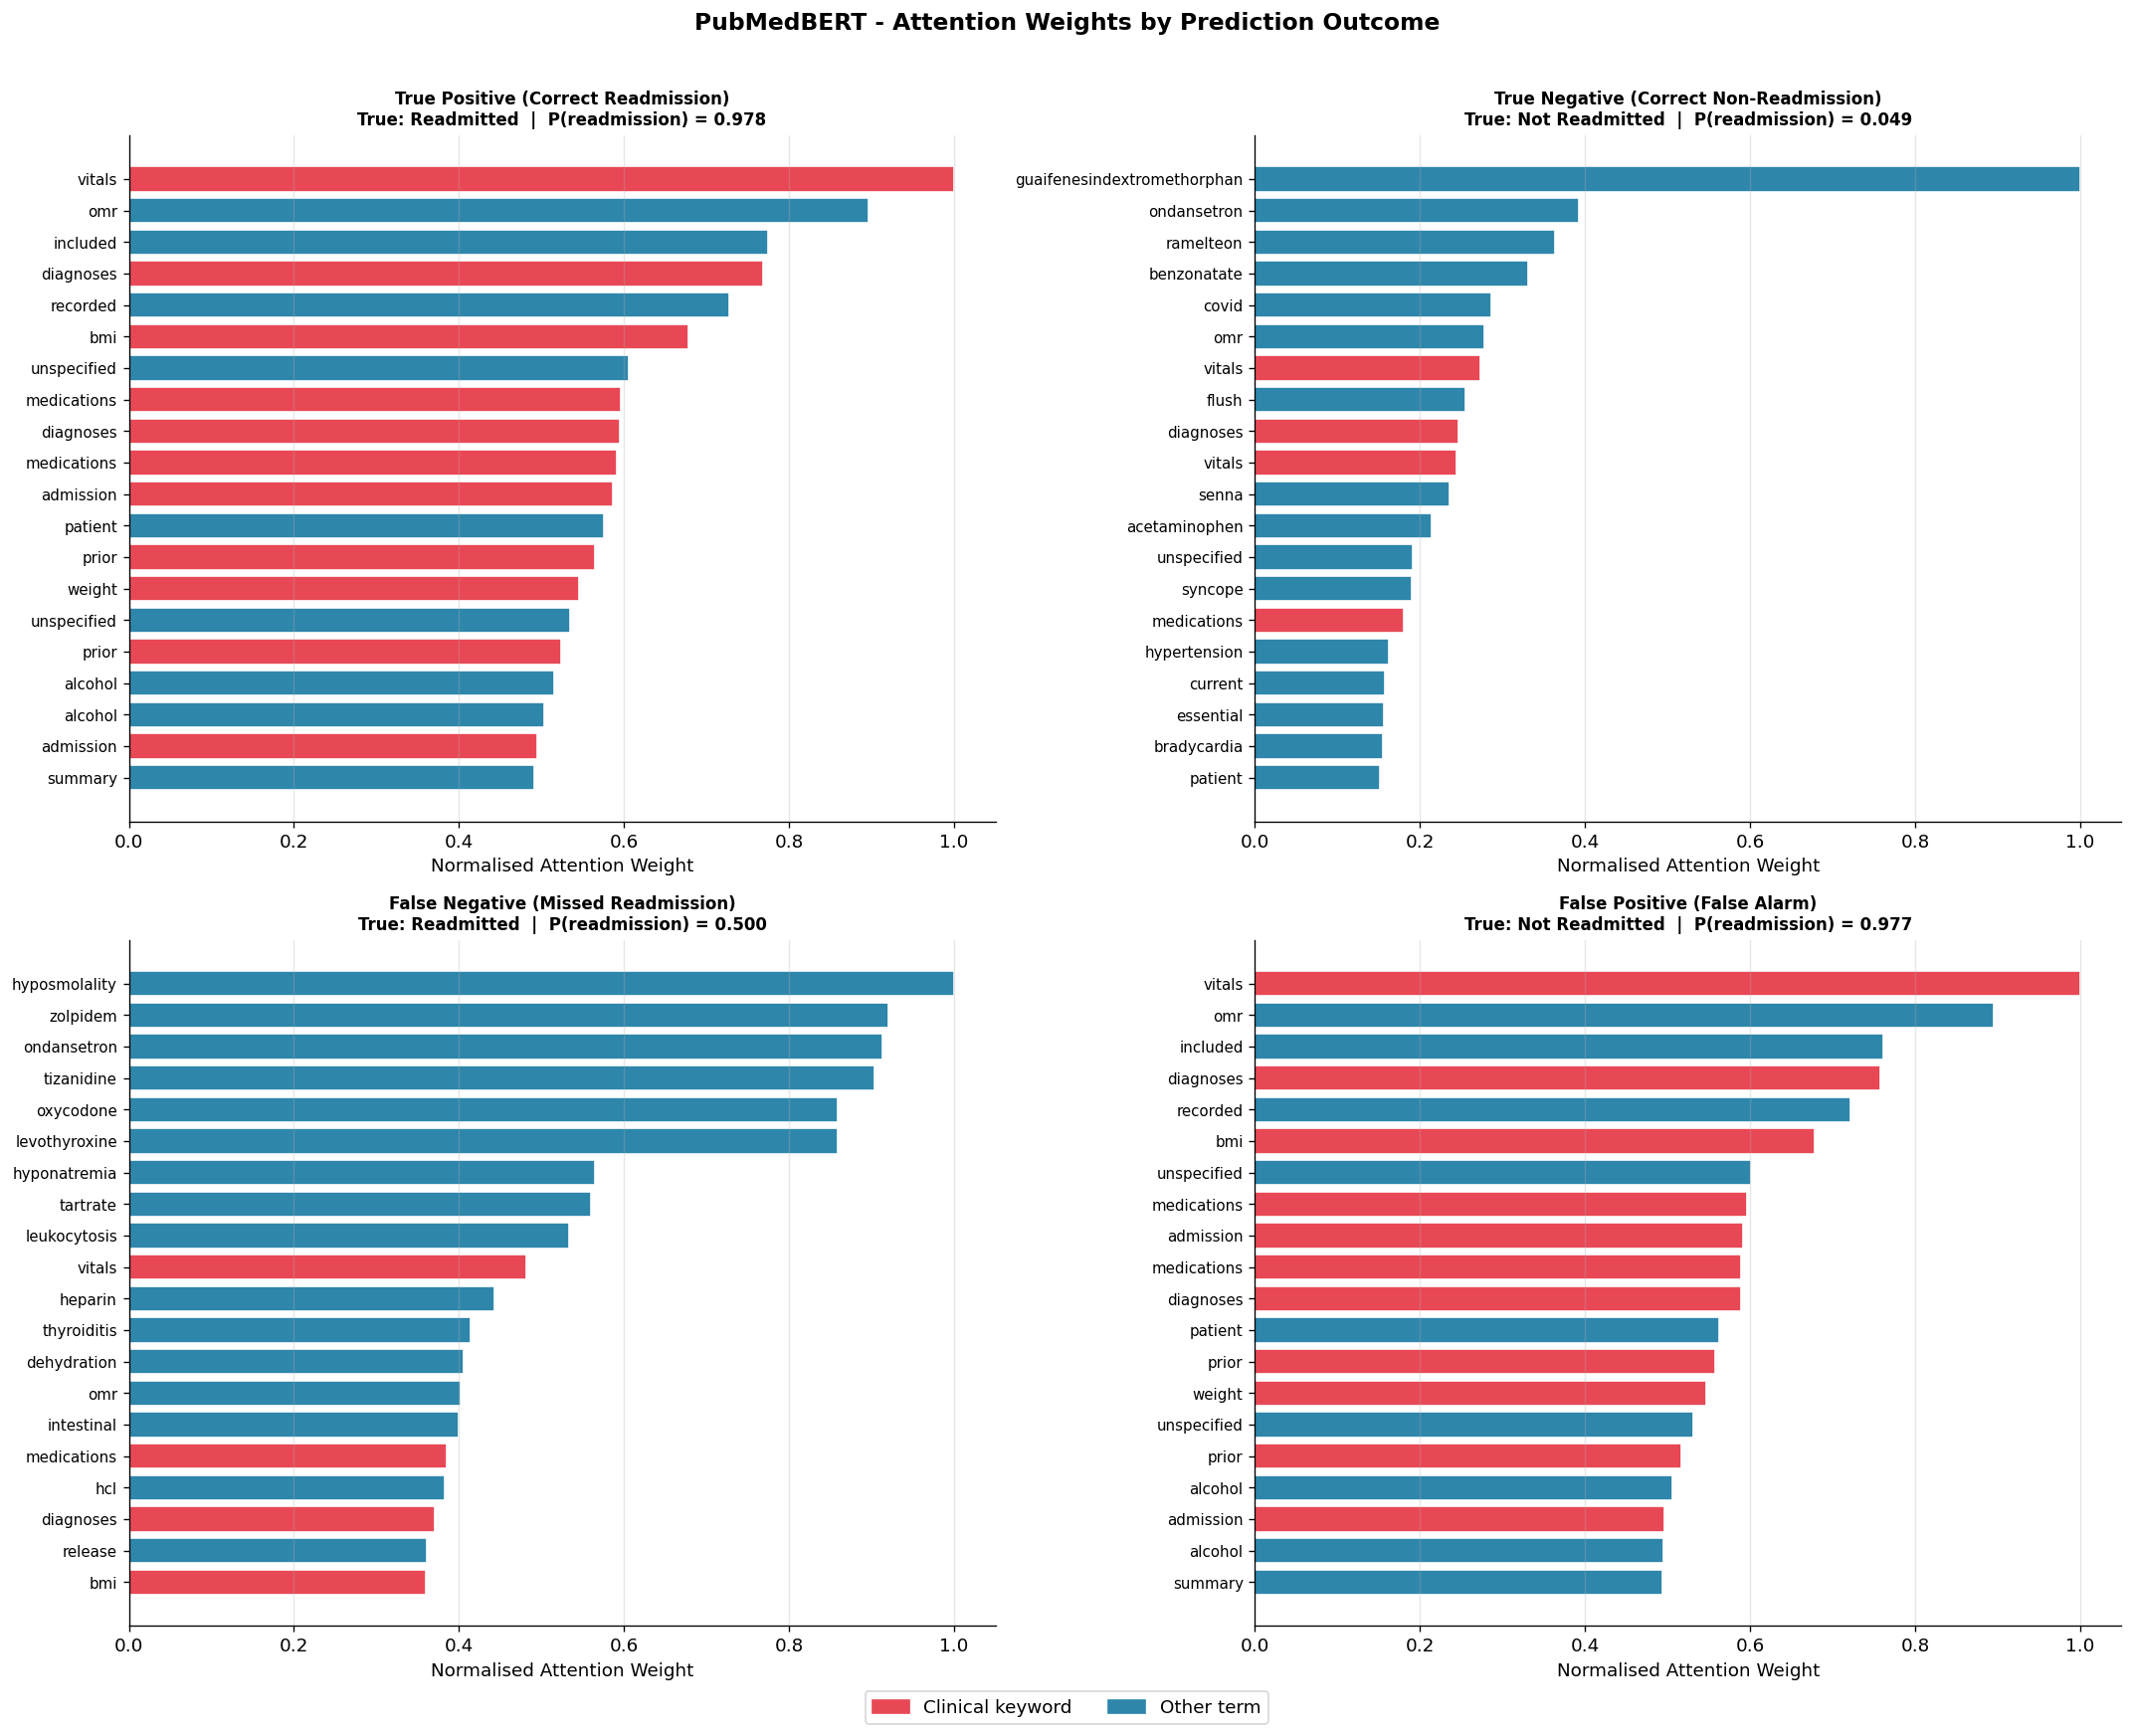

In [4]:
# Select Representative Samples by Prediction Outcome
tp_idx = np.where((y_pred == 1) & (y_test == 1))[0]
tn_idx = np.where((y_pred == 0) & (y_test == 0))[0]
fn_idx = np.where((y_pred == 0) & (y_test == 1))[0]
fp_idx = np.where((y_pred == 1) & (y_test == 0))[0]

# Select Highest-Confidence Sample from Each Outcome Group
samples = {
    'True Positive (Correct Readmission)': tp_idx[np.argmax(y_prob[tp_idx])],
    'True Negative (Correct Non-Readmission)': tn_idx[np.argmin(y_prob[tn_idx])],
    'False Negative (Missed Readmission)': fn_idx[np.argmax(y_prob[fn_idx])],
    'False Positive (False Alarm)': fp_idx[np.argmax(y_prob[fp_idx])],
}

# Create Multi-Panel Figure
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, (title, idx) in zip(axes, samples.items()):
    text = X_test[idx]
    label = y_test[idx]
    prob = y_prob[idx]

    # Extract token-level attention and reconstruct whole-word attention
    tokens, attn, logit = get_attention_weights(text, model, tokenizer)
    words, word_attn = tokens_to_words(tokens, attn)

    # Normalise attention weights for comparability within each sample
    if word_attn.max() > 0:
        word_attn = word_attn / word_attn.max()

    # Select top 20 most attended words
    top_idx = np.argsort(word_attn)[-20:]
    top_words = [words[i] for i in top_idx]
    top_attn = word_attn[top_idx]

    # Highlight clinically meaningful keywords
    clinical_keywords = {
        'prior', 'admission', 'readmission', 'diagnoses', 'medications',
        'laboratory', 'abnormal', 'icu', 'admitted', 'history',
        'bmi', 'weight', 'vitals', 'days', 'labs'
    }
    bar_colors = [
        PALETTE[1] if w.lower() in clinical_keywords else PALETTE[0]
        for w in top_words
    ]

    # Plot horizontal attention bar chart
    ax.barh(range(len(top_words)), top_attn, color=bar_colors, edgecolor='white')
    ax.set_yticks(range(len(top_words)))
    ax.set_yticklabels(top_words, fontsize=9)
    ax.set_xlabel('Normalised Attention Weight')

    label_str = 'Readmitted' if label == 1 else 'Not Readmitted'
    ax.set_title(
        f'{title}\nTrue: {label_str}  |  P(readmission) = {prob:.3f}',
        fontweight='bold',
        fontsize=10
    )
    ax.grid(True, axis='x', alpha=0.3)

# Add Figure-Level Legend
import matplotlib.patches as mpatches

legend_elements = [
    mpatches.Patch(color=PALETTE[1], label='Clinical keyword'),
    mpatches.Patch(color=PALETTE[0], label='Other term'),
]
fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=2,
    fontsize=11,
    bbox_to_anchor=(0.5, -0.02)
)

# Add Overall Title and Save Figure
plt.suptitle(
    f'{best_model_name} - Attention Weights by Prediction Outcome',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.savefig(
    f'{ATTENTION_DIR}/att_01_sample_attention.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

## Global Attention Patterns Across Test Samples

This section analyses aggregate attention patterns across multiple test samples to identify globally important terms. Rather than focusing on individual cases, this approach captures consistent attention behaviour across the dataset.

A subset of test samples is selected, and attention weights are extracted and normalised for each instance. Words are then grouped based on the predicted class, allowing separate analysis for readmitted and non-readmitted predictions.

Attention scores are aggregated and normalised by word frequency to compute average importance. This ensures that frequently occurring words do not dominate purely due to repetition, but instead reflect consistent attention across samples.

The most attended words for each predicted class are then identified, providing insight into the key terms that drive model decisions. This analysis helps reveal whether the model focuses on clinically meaningful patterns at a global level.

In [5]:
# Aggregate Attention Across Test Samples
SAMPLE_N = min(300, len(X_test))
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_test), size=SAMPLE_N, replace=False)

print(f'Extracting attention from {SAMPLE_N} test samples...')

word_attn_pos = {}
word_attn_neg = {}
word_count = {}

for i, idx in enumerate(sample_idx):
    # Report progress periodically during extraction
    if i % 75 == 0:
        print(f'  Progress: {i}/{SAMPLE_N}')

    tokens, attn, _ = get_attention_weights(X_test[idx], model, tokenizer)
    words, word_attn = tokens_to_words(tokens, attn)

    # Normalise attention within each sample
    if word_attn.max() > 0:
        word_attn = word_attn / word_attn.max()

    # Group attention by predicted class
    target = word_attn_pos if y_pred[idx] == 1 else word_attn_neg

    for w, a in zip(words, word_attn):
        # tokens_to_words already applies lowercasing and filtering
        target[w] = target.get(w, 0.0) + float(a)
        word_count[w] = word_count.get(w, 0) + 1

print(f'Unique words seen: {len(word_count):,}')


# Helper Function for Ranking Words by Mean Attention
def top_words_by_attention(attn_dict, n=25, min_count=5):
    normalised = {
        w: v / word_count[w]
        for w, v in attn_dict.items()
        if word_count.get(w, 0) >= min_count
    }
    return sorted(normalised.items(), key=lambda x: x[1], reverse=True)[:n]


# Extract Most Attended Words for Each Predicted Class
top_pos = top_words_by_attention(word_attn_pos)
top_neg = top_words_by_attention(word_attn_neg)

# Summary Output
print(f'\nTop 12 attended words when predicting READMITTED ({best_model_name}):')
for w, a in top_pos[:12]:
    print(f'  {w:<30} {a:.4f}')

print(f'\nTop 12 attended words when predicting NOT READMITTED ({best_model_name}):')
for w, a in top_neg[:12]:
    print(f'  {w:<30} {a:.4f}')

Extracting attention from 300 test samples...
  Progress: 0/300
  Progress: 75/300
  Progress: 150/300
  Progress: 225/300
Unique words seen: 1,724

Top 12 attended words when predicting READMITTED (PubMedBERT):
  torsemide                      0.7136
  piccmidline                    0.5919
  diverticulitis                 0.5843
  prochlorperazine               0.5556
  varices                        0.5550
  pancytopenia                   0.5542
  lactulose                      0.5498
  poisoning                      0.5319
  hyposmolality                  0.5012
  ascites                        0.4059
  fluticasonesalmeterol          0.4000
  antineoplastic                 0.3990

Top 12 attended words when predicting NOT READMITTED (PubMedBERT):
  lisinopril                     0.7909
  diltiazem                      0.7813
  ipratropium                    0.7752
  oxycodoneacetaminophen         0.7553
  zolpidem                       0.7446
  postprocedural                 0.7155


## Aggregate Attention Visualisation by Predicted Class

This section visualises the most influential words identified through aggregate attention analysis for each predicted class. The aim is to highlight the terms that consistently receive high attention across multiple samples.

For each class, the top attended words are selected based on their average normalised attention weights. These words represent the most important features used by the model when predicting readmission or non-readmission.

The results are presented using horizontal bar charts, allowing clear comparison of word importance within each class. Terms are ordered by attention strength to emphasise the most influential features.

This visualisation supports interpretation of global attention patterns and helps assess whether the model focuses on clinically meaningful concepts when making predictions.

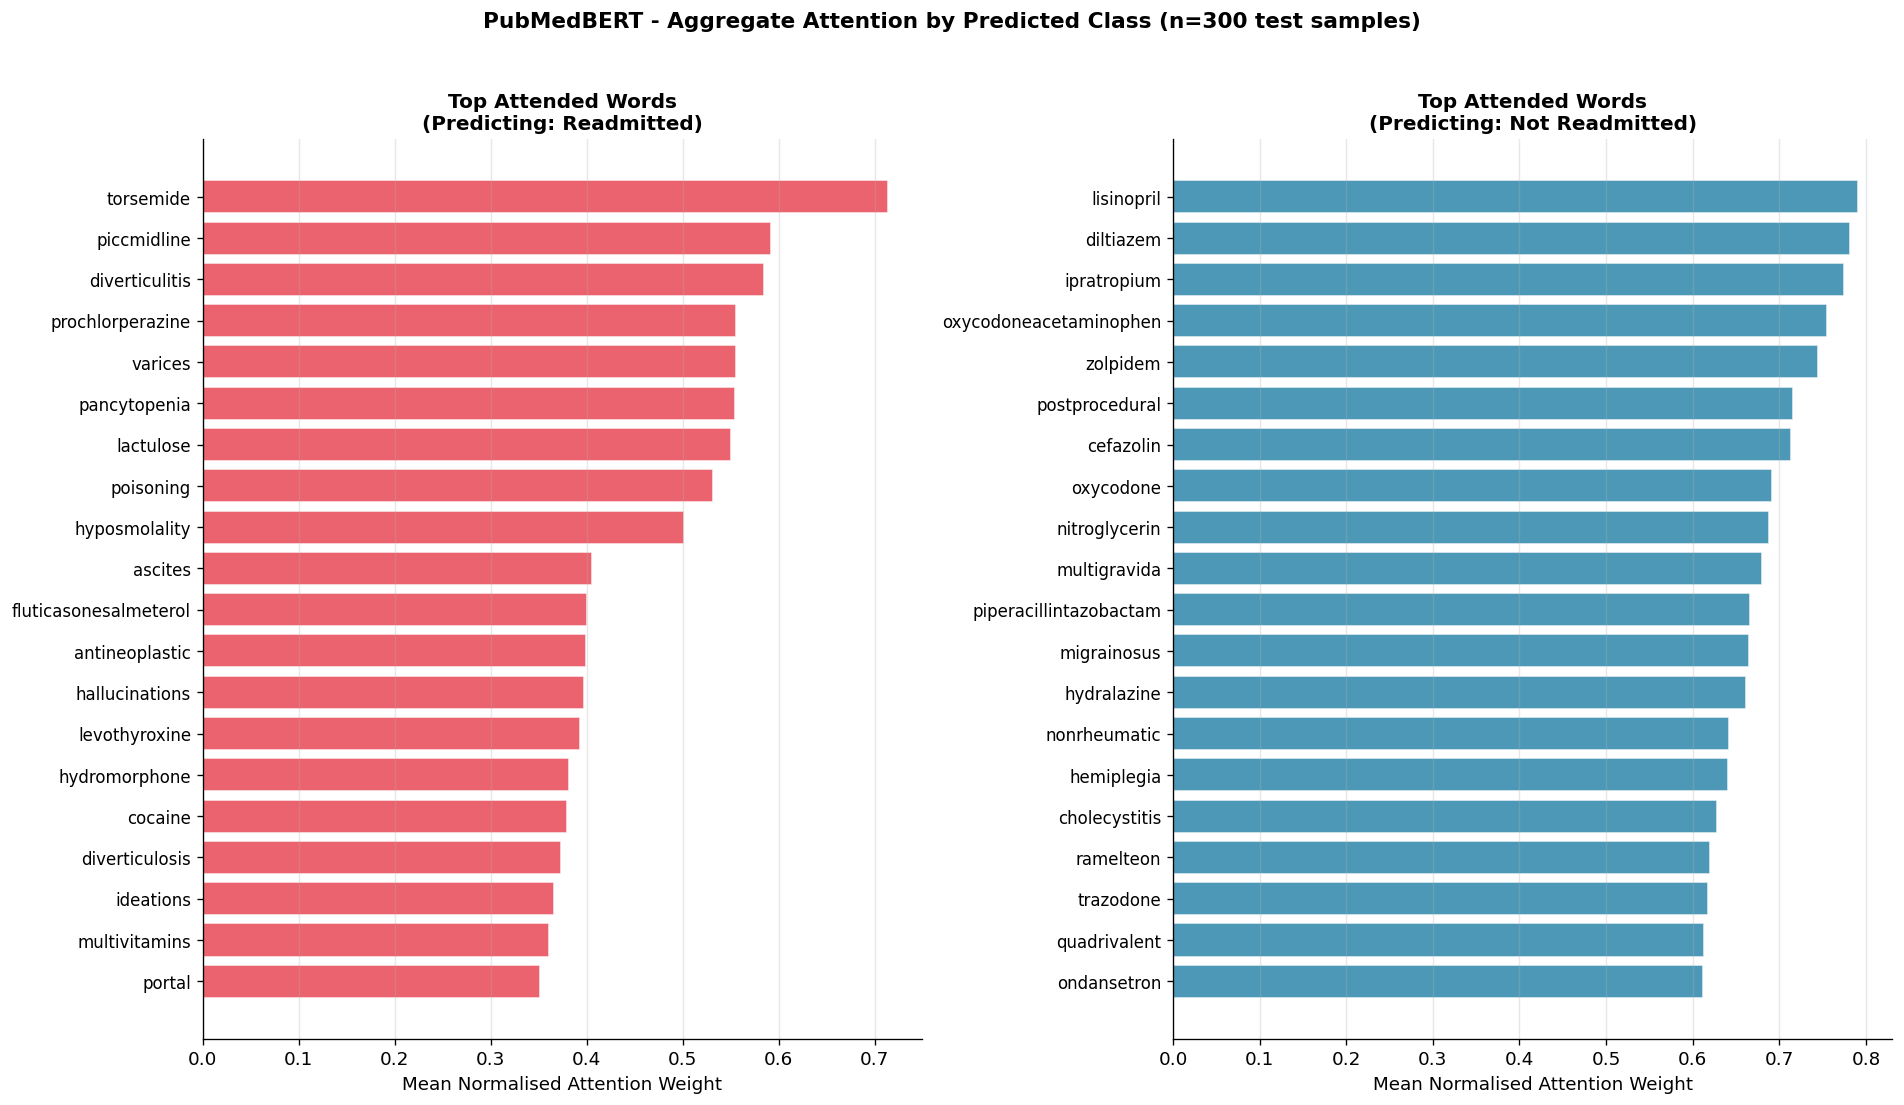

In [6]:
# Plot Top Attended Words by Predicted Class
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

for ax, top_items, title, color in [
    (axes[0], top_pos, 'Top Attended Words\n(Predicting: Readmitted)', PALETTE[1]),
    (axes[1], top_neg, 'Top Attended Words\n(Predicting: Not Readmitted)', PALETTE[0]),
]:
    words = [w for w, _ in top_items[:20]]
    scores = [a for _, a in top_items[:20]]

    # Reverse order so the highest-attended term appears at the top
    ax.barh(
        range(len(words)),
        scores[::-1],
        color=color,
        edgecolor='white',
        alpha=0.85
    )
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words[::-1], fontsize=10)
    ax.set_xlabel('Mean Normalised Attention Weight')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.grid(True, axis='x', alpha=0.3)

# Add Overall Title and Save Figure
plt.suptitle(
    f'{best_model_name} - Aggregate Attention by Predicted Class (n=300 test samples)',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(
    f'{ATTENTION_DIR}/att_02_aggregate_attention_by_class.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

## Clinical Domain-Level Attention Analysis

This section examines how the model distributes attention across clinically meaningful domains. Instead of analysing individual words in isolation, terms are grouped into predefined medical categories such as diagnostic conditions, medications, laboratory indicators, temporal context, and ICU-related concepts.

Attention scores are aggregated across both predicted classes and normalised by word frequency to obtain stable estimates of importance. Only terms with sufficient occurrence frequency are retained to ensure statistical reliability.

For each clinical domain, the mean attention weights of relevant terms are visualised using horizontal bar charts. This allows direct comparison of how strongly the model attends to different types of clinical information.

This analysis provides a higher-level interpretability layer, helping to determine whether the model aligns with clinical reasoning by focusing on medically relevant signals such as diagnoses, treatments, and patient history.

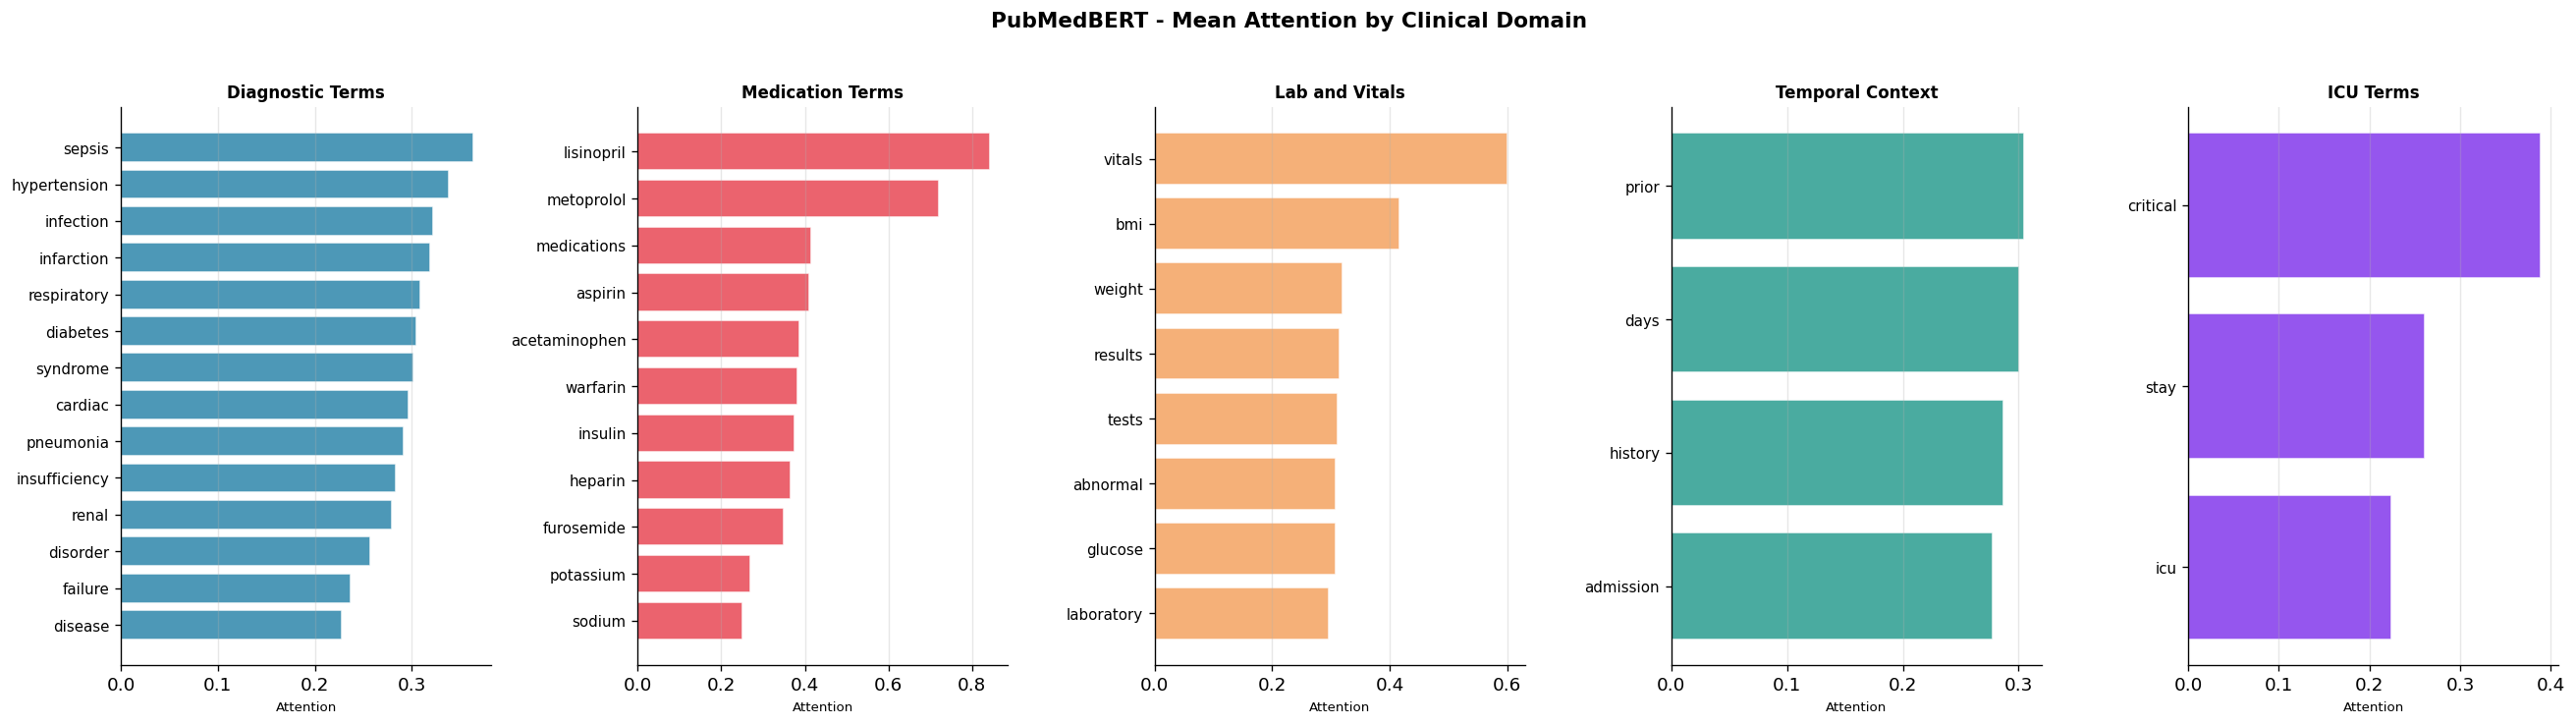

In [7]:
# Clinical Domain Attention Analysis
clinical_domains = {
    'Diagnostic Terms': [
        'infarction', 'hypertension', 'diabetes', 'failure',
        'pneumonia', 'sepsis', 'stroke', 'renal', 'cardiac',
        'respiratory', 'infection', 'disorder', 'disease',
        'insufficiency', 'syndrome'
    ],
    'Medication Terms': [
        'insulin', 'furosemide', 'metoprolol', 'heparin',
        'acetaminophen', 'potassium', 'sodium', 'warfarin',
        'aspirin', 'lisinopril', 'medications', 'medication'
    ],
    'Lab and Vitals': [
        'abnormal', 'laboratory', 'labs', 'bmi', 'weight',
        'tests', 'results', 'percent', 'creatinine',
        'glucose', 'hemoglobin', 'vitals'
    ],
    'Temporal Context': [
        'prior', 'admission', 'previous', 'readmission',
        'days', 'history', 'admissions', 'discharge'
    ],
    'ICU Terms': [
        'icu', 'intensive', 'ventilation', 'critical',
        'monitoring', 'stay'
    ],
}

# Combine Attention Across Predicted Classes
all_attn = {}

for w in set(list(word_attn_pos.keys()) + list(word_attn_neg.keys())):
    total = word_attn_pos.get(w, 0) + word_attn_neg.get(w, 0)
    cnt = word_count.get(w, 1)

    if cnt >= 3:
        all_attn[w] = total / cnt

# Plot Mean Attention by Clinical Domain
n_domains = len(clinical_domains)
fig, axes = plt.subplots(1, n_domains, figsize=(22, 6))

for ax, (domain, terms), color_idx in zip(
    axes, clinical_domains.items(), range(n_domains)
):
    # Extract attention values for terms present in the aggregated vocabulary
    domain_data = [
        (term, all_attn.get(term, 0))
        for term in terms
        if all_attn.get(term, 0) > 0
    ]

    if not domain_data:
        ax.set_visible(False)
        continue

    # Sort in ascending order for horizontal bar plotting
    domain_data.sort(key=lambda x: x[1])
    terms_plot = [d[0] for d in domain_data]
    scores = [d[1] for d in domain_data]

    ax.barh(
        range(len(terms_plot)),
        scores,
        color=PALETTE[color_idx % len(PALETTE)],
        edgecolor='white',
        alpha=0.85
    )
    ax.set_yticks(range(len(terms_plot)))
    ax.set_yticklabels(terms_plot, fontsize=9)
    ax.set_title(domain, fontweight='bold', fontsize=10)
    ax.set_xlabel('Attention', fontsize=8)
    ax.grid(True, axis='x', alpha=0.3)

# Add Overall Title and Save Figure
plt.suptitle(
    f'{best_model_name} - Mean Attention by Clinical Domain',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(
    f'{ATTENTION_DIR}/att_03_clinical_domain_attention.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

## Section-Level Attention Analysis

This section evaluates how the model distributes attention across different narrative sections of clinical text. Each section is approximated using representative keywords corresponding to common components of medical records, such as demographics, admission history, diagnoses, medications, laboratory results, vitals, and ICU status.

For each test sample, attention weights are extracted and normalised, then mapped to words. Section-level attention is computed by averaging the attention scores of keywords associated with each section. This process is performed separately for predictions of readmission and non-readmission.

The resulting mean attention values provide a structured view of which parts of the clinical narrative the model prioritises during decision-making. The comparison between predicted classes highlights whether different sections contribute differently to positive versus negative predictions.

This analysis helps assess whether the model aligns with clinical intuition—for example, by placing greater emphasis on prior admissions, diagnoses, or abnormal lab findings when predicting readmission risk.

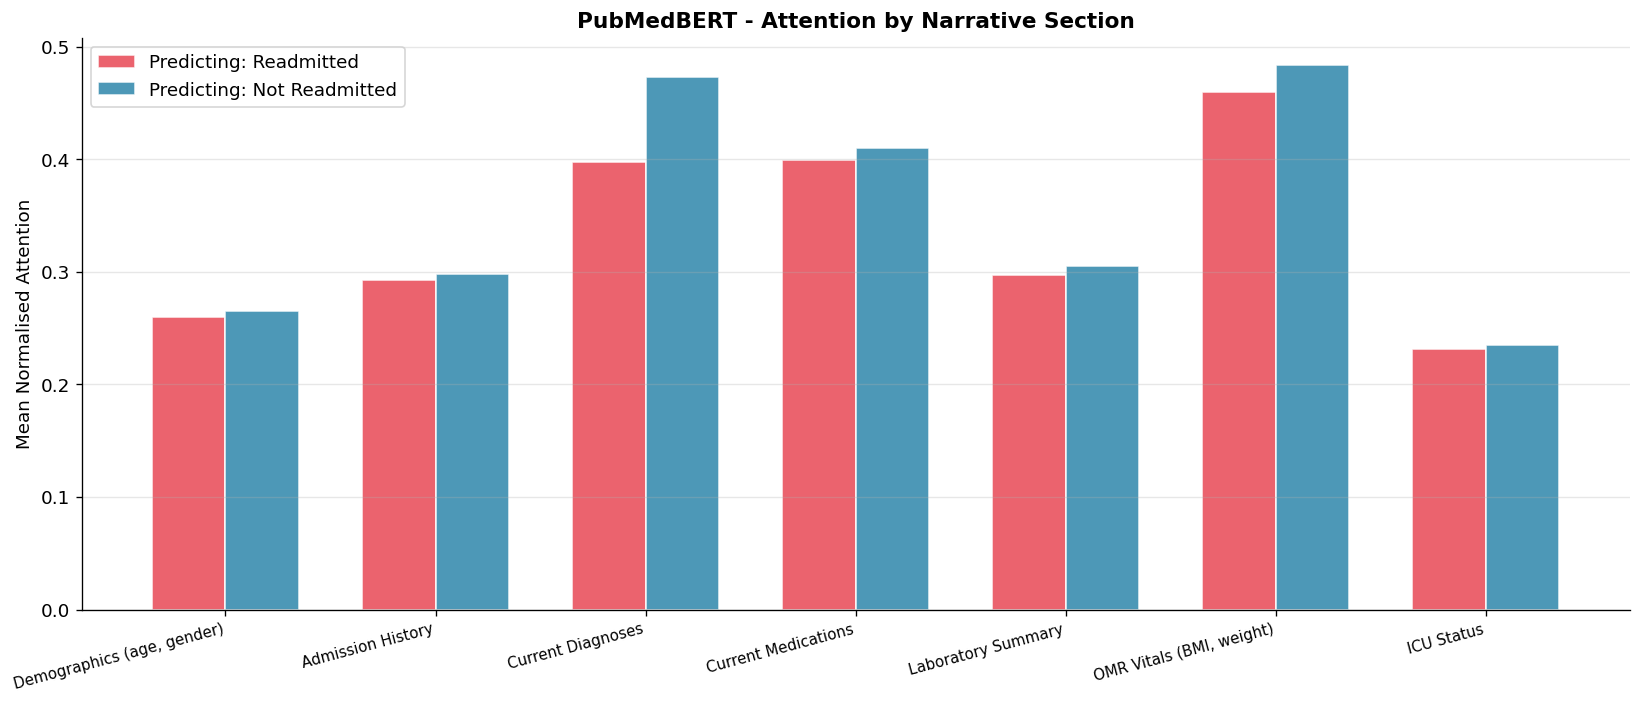

In [8]:
# Section-Level Attention Analysis
section_keywords = {
    'Demographics (age, gender)': ['patient', 'year', 'old', 'male', 'female'],
    'Admission History': ['admission', 'prior', 'admissions', 'previously'],
    'Current Diagnoses': ['diagnoses', 'diagnosis', 'diagnosed'],
    'Current Medications': ['medications', 'medication'],
    'Laboratory Summary': ['laboratory', 'labs', 'abnormal', 'percent', 'tests'],
    'OMR Vitals (BMI, weight)': ['vitals', 'bmi', 'weight'],
    'ICU Status': ['icu', 'intensive', 'stay'],
}

# Compute Mean Attention for Each Section Across All Sampled Test Cases
section_attn_pos = {s: [] for s in section_keywords}
section_attn_neg = {s: [] for s in section_keywords}

for i, idx in enumerate(sample_idx):
    tokens, attn, _ = get_attention_weights(X_test[idx], model, tokenizer)
    words, word_attn = tokens_to_words(tokens, attn)

    # Normalise attention within each sample
    if word_attn.max() > 0:
        word_attn = word_attn / word_attn.max()

    # Convert word-level attention into a lookup dictionary
    word_dict = {w.lower(): float(a) for w, a in zip(words, word_attn)}

    # Separate aggregation by predicted class
    target = section_attn_pos if y_pred[idx] == 1 else section_attn_neg

    # Estimate section attention using representative keywords
    for section, keywords in section_keywords.items():
        section_scores = [word_dict.get(kw, 0) for kw in keywords if kw in word_dict]
        if section_scores:
            target[section].append(np.mean(section_scores))

# Compute Mean Attention Per Narrative Section
pos_means = {s: np.mean(v) if v else 0 for s, v in section_attn_pos.items()}
neg_means = {s: np.mean(v) if v else 0 for s, v in section_attn_neg.items()}

sections = list(section_keywords.keys())
pos_vals = [pos_means[s] for s in sections]
neg_vals = [neg_means[s] for s in sections]

# Plot Attention by Section and Predicted Class
x = np.arange(len(sections))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    x - w / 2,
    pos_vals,
    w,
    label='Predicting: Readmitted',
    color=PALETTE[1],
    edgecolor='white',
    alpha=0.85
)
ax.bar(
    x + w / 2,
    neg_vals,
    w,
    label='Predicting: Not Readmitted',
    color=PALETTE[0],
    edgecolor='white',
    alpha=0.85
)

ax.set_xticks(x)
ax.set_xticklabels(sections, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Mean Normalised Attention')
ax.set_title(
    f'{best_model_name} - Attention by Narrative Section',
    fontweight='bold',
    fontsize=13
)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

# Save and Display Figure
plt.tight_layout()
plt.savefig(
    f'{ATTENTION_DIR}/att_04_section_attention.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

## Interpretability Summary of Attention Patterns

This section summarises the key findings from the attention analysis of the best-performing transformer model. The focus is on identifying the most influential terms that drive predictions for both readmission and non-readmission cases.

The top attended terms for each class are ranked based on their average normalised attention weights. These terms represent the features the model consistently prioritises during inference.

For readmission predictions, highly attended terms typically reflect indicators of clinical severity, prior medical history, or ongoing treatment. In contrast, terms associated with non-readmission predictions tend to reflect stable conditions or less critical clinical contexts.

This summary provides a concise interpretation of the model’s decision-making behaviour, helping to validate whether the learned patterns align with expected clinical reasoning and domain knowledge.

In [9]:
# Interpretability Summary Report
print(f'Attention Analysis Summary - {best_model_name} (Best Model)')
print('-' * 65)

print('\nTop 10 attended terms when predicting READMISSION:')
for rank, (w, a) in enumerate(top_pos[:10], 1):
    print(f'  {rank:>2}. {w:<30} attention = {a:.4f}')

print('\nTop 10 attended terms when predicting NO READMISSION:')
for rank, (w, a) in enumerate(top_neg[:10], 1):
    print(f'  {rank:>2}. {w:<30} attention = {a:.4f}')

Attention Analysis Summary - PubMedBERT (Best Model)
-----------------------------------------------------------------

Top 10 attended terms when predicting READMISSION:
   1. torsemide                      attention = 0.7136
   2. piccmidline                    attention = 0.5919
   3. diverticulitis                 attention = 0.5843
   4. prochlorperazine               attention = 0.5556
   5. varices                        attention = 0.5550
   6. pancytopenia                   attention = 0.5542
   7. lactulose                      attention = 0.5498
   8. poisoning                      attention = 0.5319
   9. hyposmolality                  attention = 0.5012
  10. ascites                        attention = 0.4059

Top 10 attended terms when predicting NO READMISSION:
   1. lisinopril                     attention = 0.7909
   2. diltiazem                      attention = 0.7813
   3. ipratropium                    attention = 0.7752
   4. oxycodoneacetaminophen         attention